In [2]:
import pandas as pd
df = pd.read_csv(r"C:\PROJECT\Probforecast\data\raw\PJME_hourly.csv")
df.head()


,Datetime,PJME_MW
0,2002-12-31 01:00:00,26498.0
1,2002-12-31 02:00:00,25147.0
2,2002-12-31 03:00:00,24574.0
3,2002-12-31 04:00:00,24393.0
4,2002-12-31 05:00:00,24860.0


In [3]:
# Check structural dimensions and data types
print("--- Dataset Information ---")
df.info()

# Count any missing (null) values per column
print("\n--- Missing Values Count ---")
print(df.isnull().sum())

--- Dataset Information ---
<class 'pandas.DataFrame'>
RangeIndex: 145366 entries, 0 to 145365
Data columns (total 2 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   Datetime  145366 non-null  str    
 1   PJME_MW   145366 non-null  float64
dtypes: float64(1), str(1)
memory usage: 2.2 MB

--- Missing Values Count ---
Datetime    0
PJME_MW     0
dtype: int64


In [4]:
# Convert text to actual datetime objects
df['Datetime'] = pd.to_datetime(df['Datetime'])

# Sort chronologically and set Datetime as the table index
df = df.sort_values('Datetime').set_index('Datetime')

# Peek at the transformed structure
df.head()

,PJME_MW
Datetime,
2002-01-01 01:00:00,30393.0
2002-01-01 02:00:00,29265.0
2002-01-01 03:00:00,28357.0
2002-01-01 04:00:00,27899.0
2002-01-01 05:00:00,28057.0


In [5]:
# Check if any datetime indices are repeated
duplicates_count = df.index.duplicated().sum()
print(f"Number of duplicate timestamp entries: {duplicates_count}")

# If duplicates exist, group by timestamp and take the mean power consumption
if duplicates_count > 0:
    df = df.groupby(level=0).mean()
    print("Duplicates handled: Consolidated timeline down to unique hourly steps.")

Number of duplicate timestamp entries: 4
Duplicates handled: Consolidated timeline down to unique hourly steps.


In [6]:
# Generate descriptive statistics for the energy consumption (MW)
df.describe()

,PJME_MW
count,145362.000000
mean,32080.507722
std,6463.870519
min,14544.000000
25%,27573.000000
50%,31421.000000
75%,35650.000000
max,62009.000000


Matplotlib is building the font cache; this may take a moment.


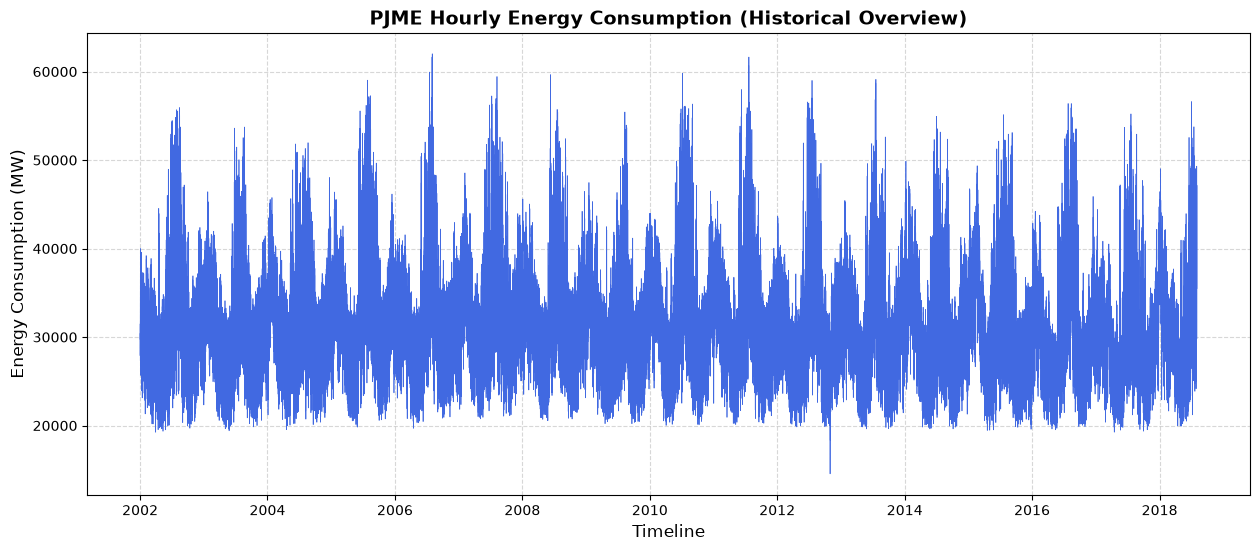

In [8]:
import matplotlib.pyplot as plt

# Set up a wide canvas for the time series
plt.figure(figsize=(15, 6))

# Plot the entire historical energy load timeline
plt.plot(df.index, df['PJME_MW'], color='royalblue', linewidth=0.5)

# Add clean labels and styling
plt.title('PJME Hourly Energy Consumption (Historical Overview)', fontsize=14, fontweight='bold')
plt.xlabel('Timeline', fontsize=12)
plt.ylabel('Energy Consumption (MW)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)

# Render the plot cleanly
plt.show()

In [9]:
def create_time_features(data_frame):
    """
    Extracts chronological features based on the DataFrame's datetime index.
    """
    # Create a copy to prevent modifying the original dataframe in place
    target_df = data_frame.copy()
    
    # Extract structural time components
    target_df['hour'] = target_df.index.hour
    target_df['dayofweek'] = target_df.index.dayofweek
    target_df['quarter'] = target_df.index.quarter
    target_df['month'] = target_df.index.month
    target_df['year'] = target_df.index.year
    target_df['dayofyear'] = target_df.index.dayofyear
    
    return target_df

# Apply the feature extraction function to our dataset
df_features = create_time_features(df)

# Look at the new columns added to the matrix
df_features.head()

,PJME_MW,hour,dayofweek,quarter,month,year,dayofyear
Datetime,,,,,,,
2002-01-01 01:00:00,30393.0,1,1,1,1,2002,1
2002-01-01 02:00:00,29265.0,2,1,1,1,2002,1
2002-01-01 03:00:00,28357.0,3,1,1,1,2002,1
2002-01-01 04:00:00,27899.0,4,1,1,1,2002,1
2002-01-01 05:00:00,28057.0,5,1,1,1,2002,1


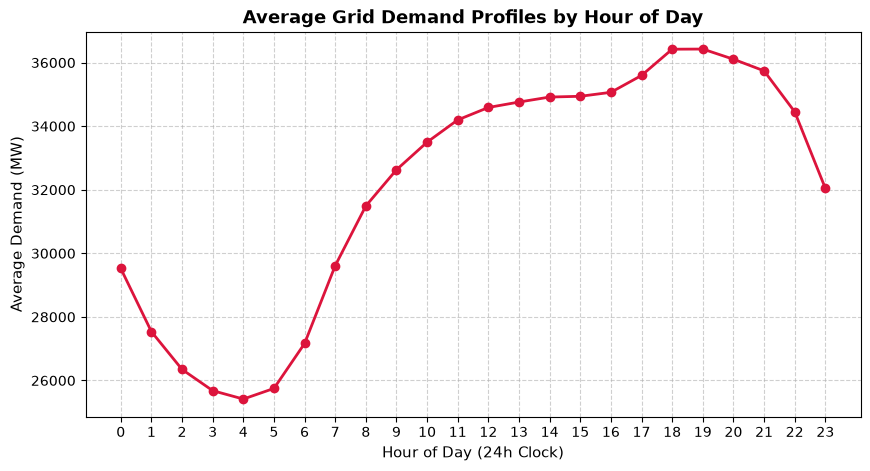

In [10]:
import matplotlib.pyplot as plt

# Calculate the average megawatt demand for every hour across the entire dataset
hourly_averages = df_features.groupby('hour')['PJME_MW'].mean()

# Plot the hourly profile
plt.figure(figsize=(10, 5))
plt.plot(hourly_averages.index, hourly_averages.values, marker='o', color='crimson', linewidth=2)

# Customizing the visual layout
plt.title('Average Grid Demand Profiles by Hour of Day', fontsize=13, fontweight='bold')
plt.xlabel('Hour of Day (24h Clock)', fontsize=11)
plt.ylabel('Average Demand (MW)', fontsize=11)
plt.xticks(range(0, 24))
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()

In [11]:
print(f"Data starts on: {df_features.index.min()}")
print(f"Data ends on:   {df_features.index.max()}")

Data starts on: 2002-01-01 01:00:00
Data ends on:   2018-08-03 00:00:00
